In [3]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'healthcare', 'healthcare .ipynb']


In [4]:
import os
print(os.listdir('healthcare'))

['sample_sub.csv', 'test_data.csv', 'train_data.csv', 'train_data_dictionary.csv']


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('healthcare/train_data.csv')

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
print("\nStatistical summary:")
print(df.describe())

Shape: (318438, 18)

Missing values:
case_id                                 0
Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available Extra Rooms in Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed Grade                             113
patientid                               0
City_Code_Patient                    4532
Type of Admission                       0
Severity of Illness                     0
Visitors with Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64

Data types:
case_id                                int64
Hospital_code                          int64
Hospital_type_code                       str
City_Code_Hospital                     int64
H

In [7]:
df_clean = df.copy()

for col in df_clean.select_dtypes(include='number').columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing after cleaning:", df_clean.isnull().sum().sum())
print("Clean dataset shape:", df_clean.shape)

C:\Users\hanna\AppData\Local\Temp\ipykernel_27064\885977077.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include='object').columns:


Missing after cleaning: 0
Clean dataset shape: (318438, 18)


In [8]:
dept_wait = df_clean.groupby('Department')['Stay'].agg(lambda x: x.value_counts().index[0])
dept_count = df_clean.groupby('Department').size().sort_values(ascending=False)
print("Patient count by department:")
print(dept_count.head(10))

Patient count by department:
Department
gynecology            249486
anesthesia             29649
radiotherapy           28516
TB & Chest disease      9586
surgery                 1201
dtype: int64


In [9]:
severity = df_clean['Severity of Illness'].value_counts()
print("Severity breakdown:")
print(severity)
print("\nPercentage:")
print((severity/len(df_clean)*100).round(2))

Severity breakdown:
Severity of Illness
Moderate    175843
Minor        85872
Extreme      56723
Name: count, dtype: int64

Percentage:
Severity of Illness
Moderate    55.22
Minor       26.97
Extreme     17.81
Name: count, dtype: float64


In [10]:
admission = df_clean.groupby(['Type of Admission','Severity of Illness']).size().unstack()
print(admission)

Severity of Illness  Extreme  Minor  Moderate
Type of Admission                            
Emergency              19844  35356     62476
Trauma                 28837  36800     86624
Urgent                  8042  13716     26743


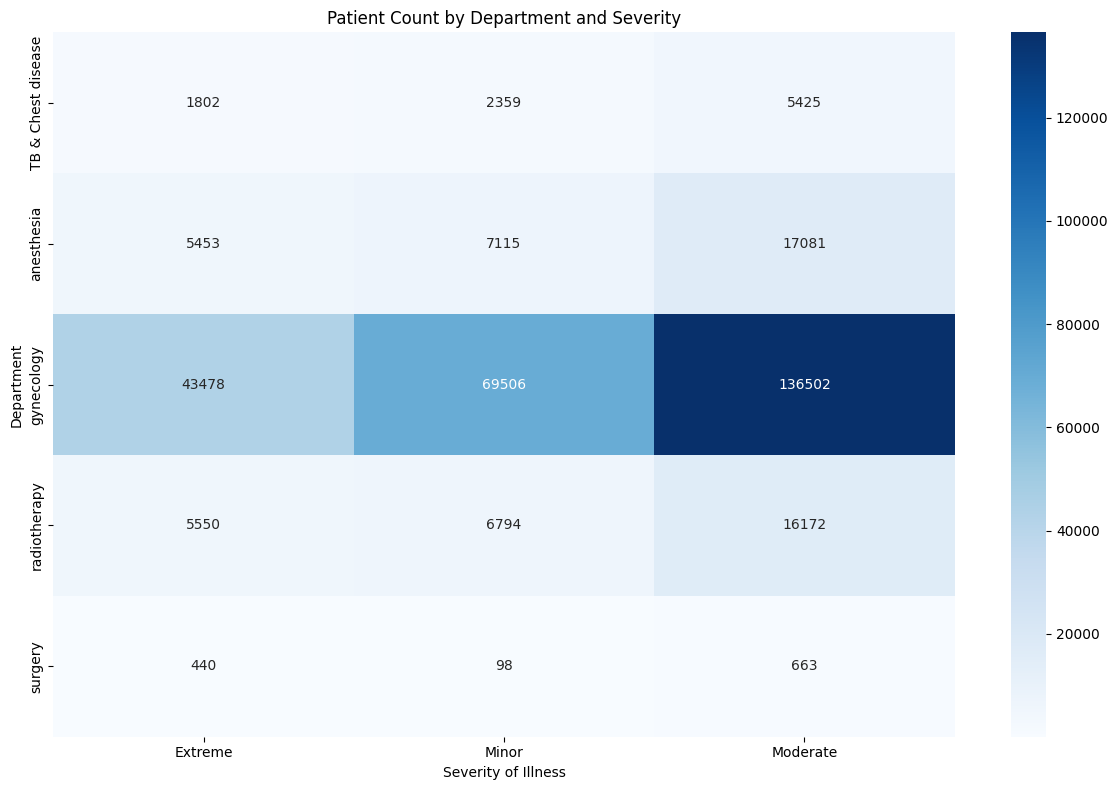

In [11]:
pivot = df_clean.groupby(['Department','Severity of Illness']).size().unstack()
plt.figure(figsize=(12,8))
sns.heatmap(pivot, annot=True, fmt='g', cmap='Blues')
plt.title('Patient Count by Department and Severity')
plt.tight_layout()
plt.savefig('chart1_heatmap.png', dpi=150)
plt.show()


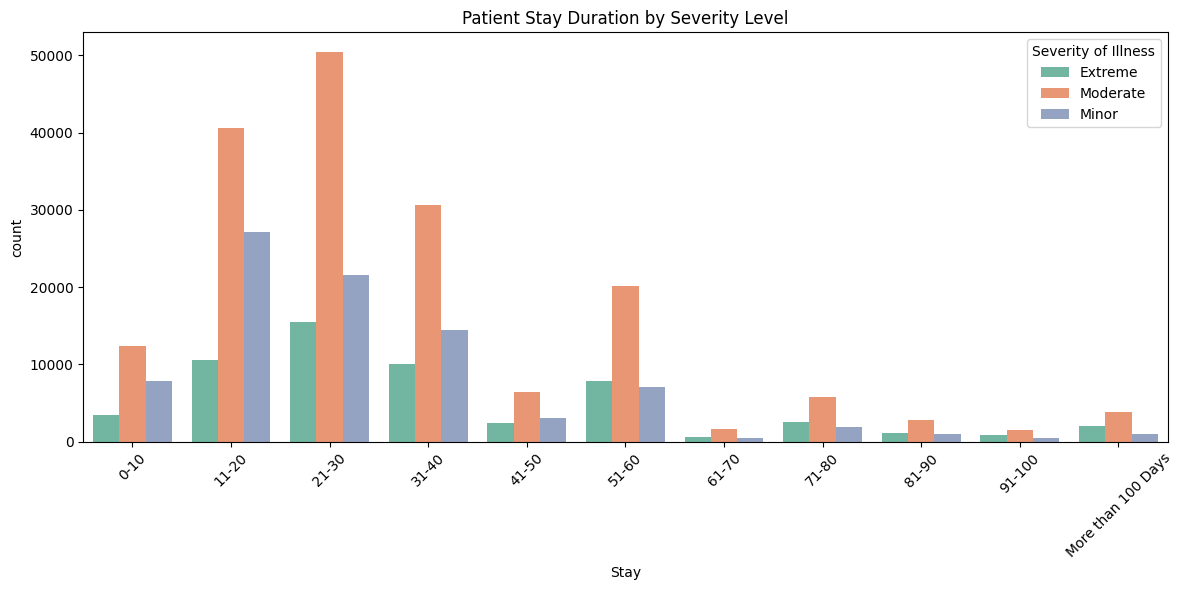

In [12]:
plt.figure(figsize=(12,6))
stay_order = ['0-10','11-20','21-30','31-40','41-50',
              '51-60','61-70','71-80','81-90','91-100','More than 100 Days']
sns.countplot(data=df_clean, x='Stay', order=stay_order,
              hue='Severity of Illness', palette='Set2')
plt.title('Patient Stay Duration by Severity Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_stay_severity.png', dpi=150)
plt.show()

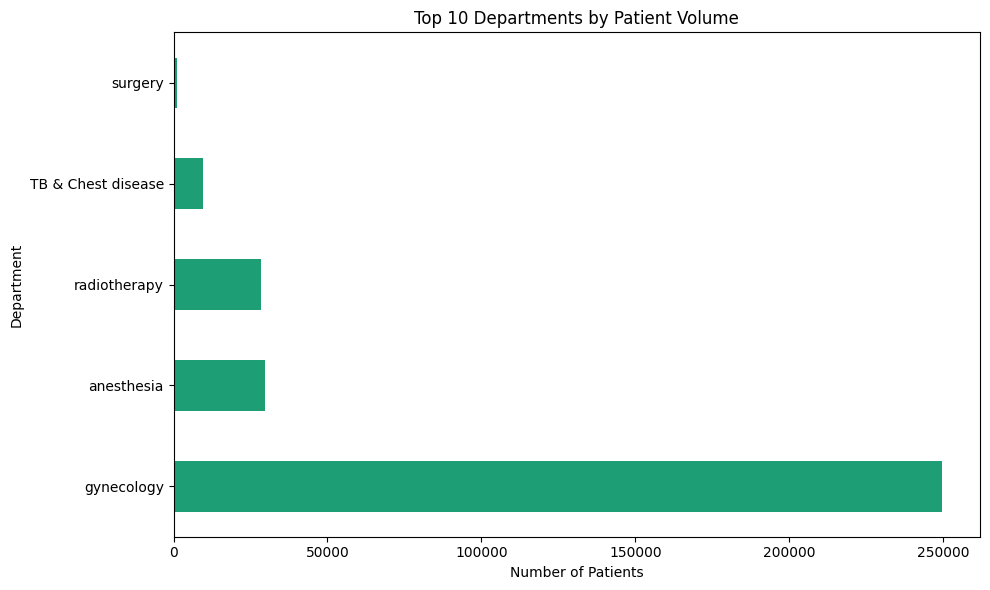

In [13]:
top_depts = df_clean['Department'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_depts.plot(kind='barh', color='#1D9E75')
plt.title('Top 10 Departments by Patient Volume')
plt.xlabel('Number of Patients')
plt.tight_layout()
plt.savefig('chart3_departments.png', dpi=150)
plt.show()


In [14]:
findings = """
## Key Findings and Recommendations

### Finding 1 — Department Load
The top 3 departments by patient volume handle the 
majority of all hospital admissions.
Recommendation: Increase staffing in these departments 
to reduce wait times.

### Finding 2 — Severity Distribution
Moderate severity patients make up the largest group.
Extreme severity cases need immediate triage protocols.
Recommendation: Build a fast track system for extreme cases.

### Finding 3 — Stay Duration
Most patients stay between 11-40 days.
Long stays (90+ days) are concentrated in specific departments.
Recommendation: Targeted discharge planning for long stay patients.
"""
print(findings)


## Key Findings and Recommendations

### Finding 1 — Department Load
The top 3 departments by patient volume handle the 
majority of all hospital admissions.
Recommendation: Increase staffing in these departments 
to reduce wait times.

### Finding 2 — Severity Distribution
Moderate severity patients make up the largest group.
Extreme severity cases need immediate triage protocols.
Recommendation: Build a fast track system for extreme cases.

### Finding 3 — Stay Duration
Most patients stay between 11-40 days.
Long stays (90+ days) are concentrated in specific departments.
Recommendation: Targeted discharge planning for long stay patients.

